# 12: Panel and Longitudinal Extensions

Most causal machine-learning examples treat each row as an independent unit observed once. Many real systems do not look like that. The same user, account, product, store, market, or patient can be observed repeatedly over time. Treatment can happen at several points, and earlier treatment can change later state, later treatment, and the final outcome.

We introduce the panel and longitudinal version of the CATE problem. Instead of asking only “what is the effect of treatment now?”, we ask:

- What is the effect of treatment in period 0 on the final outcome?
- What is the effect of treatment in period 1 on the final outcome?
- Do later treatments matter more than earlier treatments?
- How do we avoid splitting the same unit across train and test folds?
- When is a cross-sectional shortcut answering the wrong question?

EconML includes `DynamicDML`, a panel estimator for sequential treatment settings with balanced panels. We will use synthetic data with known period-specific effects so we can compare the dynamic estimates with the truth.


## Learning Goals

By the end, you should be able to:

- recognize when repeated observations violate ordinary row-level independence assumptions;
- distinguish a snapshot treatment effect from a dynamic treatment-history effect;
- construct a balanced long-format panel for `DynamicDML`;
- use `groups` so cross-fitting keeps each unit together;
- define baseline heterogeneity features `X` and time-varying controls `W`;
- estimate period-specific effects of treatment on a final outcome;
- compare dynamic estimates with cross-sectional shortcuts;
- report panel-specific diagnostics and limitations clearly.


## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use synthetic or semi-synthetic treatment-effect datasets with observable oracle effects to study **Panel And Longitudinal Extensions**. Known treatment-effect surfaces let us check whether CATE, policy, interval, and interpretability tools recover the right heterogeneity pattern.

Read each row as a customer, user, patient, seller, or operational unit with covariates measured before treatment. Effect modifiers drive heterogeneity, while controls and propensities create the observational difficulty. The experiment uses repeated observations to separate unit structure, timing, and treatment variation.

The oracle columns are teaching instruments. In a real deployment, those columns would not exist, so diagnostics, overlap checks, uncertainty, and sensitivity analysis become essential.


## Mathematical Foundation

<!-- math-foundation-note -->

Panel and longitudinal causal learning must account for time-varying state. A dynamic potential outcome can be written as

$$
Y_{i,t+1}(\bar d_t), \qquad \bar d_t=(d_{i1},\ldots,d_{it}).
$$

Sequential ignorability conditions on the observed history,

$$
D_{it}\perp\!\!\!\perp Y_{i,t+1}(\bar d_t)\mid H_{it}.
$$

Real longitudinal studies require careful timing and history construction.



We will first define the panel causal problem and the assumptions that make dynamic treatment-effect estimation credible. Then we will simulate a balanced four-period panel, where each unit receives a continuous treatment intensity in each period and has one final outcome.

After the EDA and support checks, we compare two shortcut analyses with a proper dynamic panel workflow:

1. A pooled row-level shortcut that ignores repeated observations.
2. A last-period snapshot DML analysis.
3. A `DynamicDML` model that estimates one final-outcome effect for each treatment period.

The lesson ends with segment summaries, cumulative treatment-history effects, and a reporting checklist.





## Tutorial Workflow

#### Setup

The code below imports the lesson dependencies, creates output folders, and sets plotting defaults. The warning filters remove harmless display and pandas-to-NumPy conversion messages so the saved lesson stays clean.


In [ ]:
from pathlib import Path
import os
import warnings
# Suppress optional widget warnings that can appear while importing EconML in headless notebook runs.
warnings.filterwarnings("ignore", message="IProgress not found.*")
# Keep Matplotlib cache files in a writable location during notebook execution.
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
import econml
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
# Compatibility shim for older SHAP/EconML imports under NumPy 2.x.
if not hasattr(np, "bool8"):
    np.bool8 = np.bool_
if not hasattr(np, "obj2sctype"):
    def _numpy_obj2sctype_compat(rep, default=None):
        try:
            return np.dtype(rep).type
        except TypeError:
            return default
    np.obj2sctype = _numpy_obj2sctype_compat
import pandas as pd
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 0)
import seaborn as sns
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from econml.dml import LinearDML
from econml.panel.dml import DynamicDML
warnings.filterwarnings("ignore", message="X does not have valid feature names.*", category=UserWarning)
warnings.filterwarnings("ignore", message="Not all column names are strings.*", category=UserWarning)
warnings.filterwarnings("ignore", message="Co-variance matrix is underdetermined.*", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
def find_project_root(start=None):
    """
    Find the repository root from either the repo or a nested notebook folder.
    
    Parameters
    ----------
    start : tuple[float, float]
        Starting coordinate of the arrow or edge segment.
    
    Returns
    -------
    pathlib.Path
        Repository root inferred from the current working directory or its parents.
    """
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "notebooks").exists():
            return candidate
    return Path.cwd()
PROJECT_ROOT = find_project_root()
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks" / "tutorials" / "econml"
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(202612)
print(f"Project root: {PROJECT_ROOT}")
print(f"EconML version: {econml.__version__}")


The environment is ready, and the lesson uses the `12_` prefix for its generated teaching objects.

This reproducibility check keeps the run auditable before causal interpretation begins. It makes the run consistent enough for later graphs, tables, and estimates to be checked against the same environment.
<!-- result-implication-expanded -->


### Panel Vocabulary

Panel and longitudinal settings have their own vocabulary. This table defines the terms used throughout the lesson.


| term | meaning | lesson_example |
| --- | --- | --- |
| Unit | The entity observed repeatedly over time. | A synthetic account observed for four periods. |
| Period | A time step within a unit's history. | Periods 0, 1, 2, and 3. |
| Treatment history | The sequence of treatment intensities assigned over time. | Four treatment intensity values per unit. |
| Final outcome | The outcome measured after the treatment history has unfolded. | A final value metric observed after period 3. |
| Baseline features X | Features used to describe treatment-effect heterogeneity. | Need, quality, friction, price sensitivity, and region risk. |
| Time-varying controls W | Observed state variables that change over time and affect treatment assignment or outcome. | State before treatment, seasonality, and lagged treatment. |
| Group split | A train-test or cross-fitting split that keeps all rows from a unit together. | All four periods of an account stay in the same split. |


The most important shift is from row-level thinking to unit-history thinking. A panel row is not an independent unit; it is one moment inside a unit's trajectory.


### DynamicDML Capability Map

`DynamicDML` has a specific input structure. This table summarizes what it expects and how that differs from earlier cross-sectional lessons.


| component | expected_shape | role |
| --- | --- | --- |
| Y | n_units * n_periods rows | Outcome array. DynamicDML targets the final-period outcome while using the long panel structure. |
| T | n_units * n_periods rows | Treatment assigned in each period. Effects are returned separately for each period. |
| X | n_units * n_periods rows by d_x columns | Heterogeneity features. First-period X is used for CATE heterogeneity; later X values act like controls. |
| W | n_units * n_periods rows by d_w columns | Time-varying controls that help adjust treatment and outcome nuisance models. |
| groups | n_units * n_periods rows | Unit identifier. Required so each unit's periods stay together during cross-fitting. |
| balanced panel | same number of periods per unit | DynamicDML expects equal-length histories in the installed implementation. |


This input map is the practical contract for the lesson. The synthetic data will be deliberately balanced and sorted by unit-period order.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


### Longitudinal Assumptions

Dynamic causal analysis needs more than a model. The table below lists the main assumptions and the checks we can partially support with observed data.


| assumption | plain_language | practical_check |
| --- | --- | --- |
| Sequential ignorability | At each period, treatment is as-if random after conditioning on observed history. | Include relevant lagged state and treatment history in W; inspect treatment predictability. |
| No future leakage | Features used for period t treatment cannot include information observed after treatment t. | Build features from baseline or pre-period state only. |
| Positivity over treatment histories | Comparable units have enough variation in treatment at each period. | Check treatment distributions by period and segment. |
| Stable unit histories | Each unit's history is internally ordered and not mixed with other units. | Validate one row per unit-period and group-contiguous ordering. |
| Correct estimand timing | The outcome window starts after the treatment history being evaluated. | Define treatment periods and final outcome explicitly before modeling. |


The assumptions are timing-heavy. In longitudinal work, a model can be mathematically valid but still answer the wrong question if the time ordering is wrong.


#### Example Data Design

The next step creates a balanced panel with four periods per unit. Each unit has baseline features, a time-varying state before treatment, a treatment intensity in each period, and one final outcome.

The true treatment effect varies by period and by baseline unit characteristics. Later periods are designed to have larger direct effects on the final outcome, but earlier periods still matter.


In [2]:
# Define reusable helpers for the Example Data Design section.
def true_period_effect(period, baseline_need, user_quality, region_risk, high_need_segment):
    """
    Ground-truth effect of one additional treatment unit in a specific period.
    
    Parameters
    ----------
    period : object
        Time period at which the panel or longitudinal effect is evaluated.
    baseline_need : object
        Baseline need score used in the longitudinal treatment-effect function.
    user_quality : object
        User quality score used in the longitudinal treatment-effect function.
    region_risk : object
        Regional risk score used in the longitudinal treatment-effect function.
    high_need_segment : object
        High-need segment indicator used in the longitudinal effect function.
    
    Returns
    -------
    float
        Scalar estimate or oracle value for true period effect.
    """
    period_base = np.array([0.10, 0.16, 0.24, 0.34])[period]
    period_need_slope = np.array([0.05, 0.08, 0.11, 0.15])[period]
    return (
        period_base
        + period_need_slope * baseline_need
        + 0.05 * user_quality
        - 0.04 * region_risk
        + 0.04 * high_need_segment
    )
n_units = 1_600
n_periods = 4
panel_rows = []
for unit_id in range(n_units):
    baseline_need = rng.normal(0, 1)
    user_quality = rng.normal(0, 1)
    friction_score = rng.normal(0, 1)
    price_sensitivity = rng.beta(2.2, 3.1)
    region_risk = rng.binomial(1, 0.28)
    high_need_segment = int(baseline_need > 0.55)
    state = 0.40 * baseline_need + 0.25 * user_quality - 0.15 * friction_score + rng.normal(0, 0.70)
    lagged_treatment = 0.0
    unit_rows = []
    treatments = []
    period_effects = []
    for period in range(n_periods):
        seasonality = np.sin((period + 1) / n_periods * np.pi)
        state_before_treatment = state
        treatment_intensity = (
            0.45 * baseline_need
            + 0.38 * state_before_treatment
            - 0.22 * friction_score
            - 0.15 * price_sensitivity
            + 0.12 * seasonality
            + 0.18 * lagged_treatment
            + rng.normal(0, 0.80)
        )
        tau_t = true_period_effect(period, baseline_need, user_quality, region_risk, high_need_segment)
        # State evolves after treatment. Later treatment assignment can depend on this state.
        state_after_treatment = (
            0.55 * state_before_treatment
            + 0.30 * treatment_intensity
            + 0.12 * user_quality
            - 0.08 * price_sensitivity
            + rng.normal(0, 0.55)
        )
        treatments.append(treatment_intensity)
        period_effects.append(tau_t)
        unit_rows.append(
            {
                "unit_id": unit_id,
                "period": period,
                "baseline_need": baseline_need,
                "user_quality": user_quality,
                "friction_score": friction_score,
                "price_sensitivity": price_sensitivity,
                "region_risk": region_risk,
                "high_need_segment": high_need_segment,
                "state_before_treatment": state_before_treatment,
                "seasonality": seasonality,
                "lagged_treatment": lagged_treatment,
                "treatment_intensity": treatment_intensity,
                "true_period_effect": tau_t,
            }
        )
        state = state_after_treatment
        lagged_treatment = treatment_intensity
    final_outcome = (
        1.00
        + 0.45 * baseline_need
        + 0.35 * user_quality
        - 0.25 * friction_score
        - 0.15 * price_sensitivity
        - 0.18 * region_risk
        + sum(period_effects[t] * treatments[t] for t in range(n_periods))
        + rng.normal(0, 0.75)
    )
    for row in unit_rows:
        row["final_outcome"] = final_outcome
        row["true_cumulative_effect"] = sum(period_effects)
        panel_rows.append(row)
panel_df = pd.DataFrame(panel_rows)
panel_df.to_csv(TABLE_DIR / "12_panel_teaching_data.csv", index=False)
panel_df.head(8)


,unit_id,period,baseline_need,user_quality,friction_score,price_sensitivity,region_risk,high_need_segment,state_before_treatment,seasonality,lagged_treatment,treatment_intensity,true_period_effect,final_outcome,true_cumulative_effect
0,0,0,-1.905999,0.775205,-0.566139,0.606914,0,0,-1.277153,7.071068e-01,0.000000,-1.446075,0.043460,0.085988,0.251701
1,0,1,-1.905999,0.775205,-0.566139,0.606914,0,0,-1.281670,1.000000e+00,-1.446075,-1.613141,0.046280,0.085988,0.251701
2,0,2,-1.905999,0.775205,-0.566139,0.606914,0,0,-2.145355,7.071068e-01,-1.613141,-1.228016,0.069100,0.085988,0.251701
3,0,3,-1.905999,0.775205,-0.566139,0.606914,0,0,-1.521065,1.224647e-16,-1.228016,-0.909721,0.092860,0.085988,0.251701
4,1,0,-0.891438,0.822246,1.026834,0.482701,1,0,0.776740,7.071068e-01,0.000000,-0.112005,0.056540,-0.212880,0.496788
5,1,1,-0.891438,0.822246,1.026834,0.482701,1,0,1.148675,1.000000e+00,-0.112005,-1.190097,0.089797,-0.212880,0.496788
6,1,2,-0.891438,0.822246,1.026834,0.482701,1,0,-0.491598,7.071068e-01,-1.190097,-0.659905,0.143054,-0.212880,0.496788
7,1,3,-0.891438,0.822246,1.026834,0.482701,1,0,0.985568,1.224647e-16,-0.659905,0.106291,0.207397,-0.212880,0.496788


The first eight rows show two units over four periods each. The final outcome is repeated across a unit's rows because the target is one final outcome after the full treatment history.


#### Field Dictionary

Panel lessons get confusing quickly if the role of each column is not explicit. This table separates baseline features, time-varying controls, treatment, outcome, and teaching-only truth columns.


| field | role | description |
| --- | --- | --- |
| unit_id | Panel identifier | Unique identifier for the repeated unit. |
| period | Time index | Period number inside the unit history. |
| baseline_need | Baseline feature X | Pre-history need or demand signal. |
| user_quality | Baseline feature X | Stable quality or fit signal. |
| friction_score | Baseline feature X | Stable friction signal. |
| price_sensitivity | Baseline feature X | Stable sensitivity to cost or effort. |
| region_risk | Baseline feature X | Binary marker for lower baseline outcome regions. |
| high_need_segment | Baseline feature X | Binary segment derived from baseline need. |
| state_before_treatment | Time-varying control W | Observed state immediately before period treatment. |
| seasonality | Time-varying control W | Period-specific seasonality signal. |
| lagged_treatment | Time-varying control W | Treatment intensity from the previous period. |
| treatment_intensity | Treatment T | Continuous treatment intensity assigned in each period. |
| final_outcome | Outcome Y | Outcome measured after all four treatment periods. |
| true_period_effect | Teaching-only truth | True final-outcome effect of one treatment unit in this period. |
| true_cumulative_effect | Teaching-only truth | Sum of true period effects for one-unit increases in all periods. |


The time-varying controls are observed before each period's treatment. That timing is essential; controls measured after treatment would create leakage or block part of the treatment effect.





## Diagnostics and Interpretation

### Balanced Panel Checks

`DynamicDML` expects a balanced panel in this implementation. The code below checks that every unit has exactly four periods and that there is one row for each unit-period pair.


In [3]:
period_counts = panel_df.groupby("unit_id")["period"].nunique()
duplicate_unit_periods = panel_df.duplicated(["unit_id", "period"]).sum()
balanced_panel_checks = pd.DataFrame(
    {
        "check": [
            "number_of_units",
            "rows",
            "expected_rows",
            "min_periods_per_unit",
            "max_periods_per_unit",
            "duplicate_unit_period_rows",
            "is_balanced",
        ],
        "value": [
            panel_df["unit_id"].nunique(),
            len(panel_df),
            panel_df["unit_id"].nunique() * n_periods,
            period_counts.min(),
            period_counts.max(),
            duplicate_unit_periods,
            bool((period_counts.min() == n_periods) and (period_counts.max() == n_periods) and duplicate_unit_periods == 0),
        ],
    }
)
balanced_panel_checks.to_csv(TABLE_DIR / "12_balanced_panel_checks.csv", index=False)
display(balanced_panel_checks)


,check,value
0,number_of_units,1600
1,rows,6400
2,expected_rows,6400
3,min_periods_per_unit,4
4,max_periods_per_unit,4
5,duplicate_unit_period_rows,0
6,is_balanced,True


The panel is balanced and clean. This validation step serves a different role than glamorous. It prevents a large class of panel estimator failures.

The table is useful because it compresses the evidence into a form that can be compared, audited, and tied back to the causal question.
<!-- result-implication-expanded -->





## Reporting and Takeaways

### Basic Panel Summary

The code below summarizes the number of units, treatment variation, outcome variation, and true effects. We report both row-level and unit-level quantities because a panel dataset contains repeated rows per unit.


In [4]:
unit_level = panel_df[panel_df["period"] == 0].copy()
panel_basic_summary = pd.DataFrame(
    {
        "metric": [
            "units",
            "periods_per_unit",
            "panel_rows",
            "treatment_mean",
            "treatment_std",
            "final_outcome_mean_unit_level",
            "final_outcome_std_unit_level",
            "mean_true_period_effect",
            "mean_true_cumulative_effect",
            "share_high_need_units",
        ],
        "value": [
            panel_df["unit_id"].nunique(),
            n_periods,
            len(panel_df),
            panel_df["treatment_intensity"].mean(),
            panel_df["treatment_intensity"].std(),
            unit_level["final_outcome"].mean(),
            unit_level["final_outcome"].std(),
            panel_df["true_period_effect"].mean(),
            unit_level["true_cumulative_effect"].mean(),
            unit_level["high_need_segment"].mean(),
        ],
    }
)
panel_basic_summary.to_csv(TABLE_DIR / "12_panel_basic_summary.csv", index=False)
display(panel_basic_summary)


,metric,value
0,units,1600.000000
1,periods_per_unit,4.000000
2,panel_rows,6400.000000
3,treatment_mean,-0.040500
4,treatment_std,1.184164
5,final_outcome_mean_unit_level,1.189309
6,final_outcome_std_unit_level,1.669034
7,mean_true_period_effect,0.207492
8,mean_true_cumulative_effect,0.829970
9,share_high_need_units,0.275000


The summary confirms there is treatment variation and effect heterogeneity. The cumulative effect is larger than any single period effect because it sums the impact of treatment across the history.




### Treatment and State by Period

A panel analysis should inspect how treatment and state evolve over time. This table summarizes treatment intensity and pre-treatment state by period.


In [5]:
period_summary = (
    panel_df.groupby("period")
    .agg(
        rows=("treatment_intensity", "size"),
        treatment_mean=("treatment_intensity", "mean"),
        treatment_std=("treatment_intensity", "std"),
        state_mean=("state_before_treatment", "mean"),
        state_std=("state_before_treatment", "std"),
        true_period_effect_mean=("true_period_effect", "mean"),
    )
    .reset_index()
)
period_summary.to_csv(TABLE_DIR / "12_period_summary.csv", index=False)
display(period_summary)


,period,rows,treatment_mean,treatment_std,state_mean,state_std,true_period_effect_mean
0,0,1600,-0.018062,1.071482,-0.018991,0.854051,0.099030
1,1,1600,-0.013569,1.170372,-0.063140,0.891999,0.158059
2,2,1600,-0.024575,1.204069,-0.057117,0.980278,0.237088
3,3,1600,-0.105795,1.279933,-0.061095,1.027081,0.335792


Treatment and state vary across periods. The true effect also changes by period, which is exactly why a single pooled treatment effect is not the right estimand.




### Treatment Distribution by Period

The next plot shows treatment-intensity distributions separately by period. Similar support across periods makes period-specific effect estimation more stable.


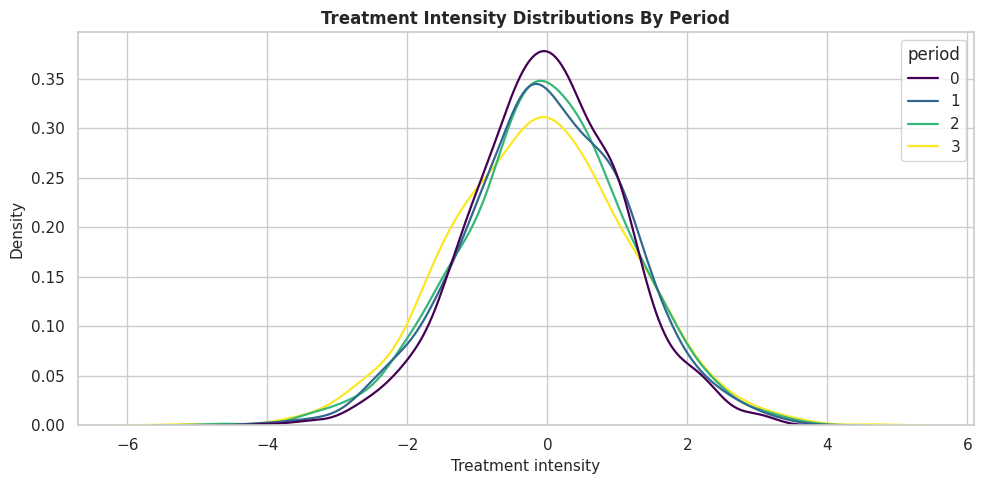

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(
    data=panel_df,
    x="treatment_intensity",
    hue="period",
    common_norm=False,
    fill=False,
    linewidth=1.6,
    palette="viridis",
    ax=ax,
)
ax.set_title("Treatment Intensity Distributions By Period")
ax.set_xlabel("Treatment intensity")
ax.set_ylabel("Density")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "12_treatment_distribution_by_period.png", dpi=160, bbox_inches="tight")
plt.show()


The distributions overlap across periods, so the dynamic estimator has treatment variation to work with in each period. If one period had almost no treatment variation, its effect would be harder to estimate.


### True Period Effect Distribution

Because this is synthetic data, we can inspect the true effect for each period. Later periods are designed to matter more on average.


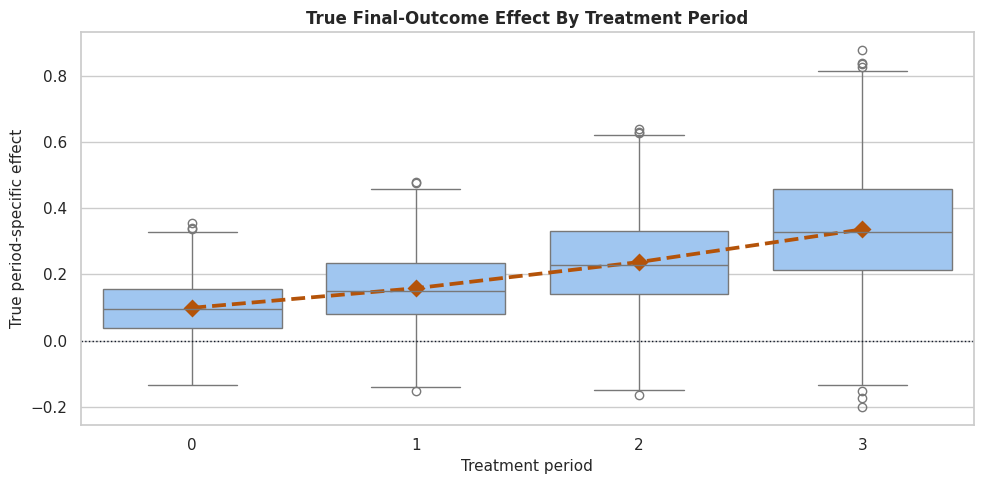

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=panel_df, x="period", y="true_period_effect", color="#93c5fd", ax=ax)
sns.pointplot(data=period_summary, x="period", y="true_period_effect_mean", color="#b45309", markers="D", linestyles="--", ax=ax)
ax.axhline(0, color="#111827", linestyle=":", linewidth=1)
ax.set_title("True Final-Outcome Effect By Treatment Period")
ax.set_xlabel("Treatment period")
ax.set_ylabel("True period-specific effect")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "12_true_period_effect_distribution.png", dpi=160, bbox_inches="tight")
plt.show()


The true effect is not constant over time. This is the main reason `DynamicDML` is more appropriate than collapsing the panel into one generic treatment row.




### Time-Varying Confounding Check

Treatment assignment depends on current state and lagged treatment. The code below quantifies those relationships by period so the adjustment problem is explicit.


In [8]:
def safe_corr(left, right):
    """
    Return a correlation, or NaN when one side is constant.
    
    Parameters
    ----------
    left : object
        Left-side value in a comparison or diagram.
    right : object
        Right-side value in a comparison or diagram.
    
    Returns
    -------
    float
        Pearson correlation, or NaN when either input has too little variation.
    """
    left = np.asarray(left)
    right = np.asarray(right)
    if np.std(left) < 1e-12 or np.std(right) < 1e-12:
        return np.nan
    return np.corrcoef(left, right)[0, 1]
time_confounding_rows = []
for period, period_df in panel_df.groupby("period"):
    time_confounding_rows.append(
        {
            "period": period,
            "corr_treatment_state_before": safe_corr(period_df["treatment_intensity"], period_df["state_before_treatment"]),
            "corr_treatment_lagged_treatment": safe_corr(period_df["treatment_intensity"], period_df["lagged_treatment"]),
            "corr_treatment_baseline_need": safe_corr(period_df["treatment_intensity"], period_df["baseline_need"]),
        }
    )
time_varying_confounding = pd.DataFrame(time_confounding_rows)
time_varying_confounding.to_csv(TABLE_DIR / "12_time_varying_confounding_checks.csv", index=False)
display(time_varying_confounding)


,period,corr_treatment_state_before,corr_treatment_lagged_treatment,corr_treatment_baseline_need
0,0,0.517404,NaN,0.570621
1,1,0.579897,0.602723,0.606140
2,2,0.618740,0.648185,0.602884
3,3,0.645019,0.672060,0.611827


The treatment is related to pre-treatment state and treatment history. A snapshot model that ignores this timing can easily answer a distorted question.

This matters because the software can only estimate the intended causal quantity when the variables have been assigned to the right design roles.
<!-- result-implication-expanded -->


#### Unit-Level Train-Test Split

Panel data must be split by unit, not by row. If the same unit appears in both train and test data, the evaluation leaks information across time from the same unit.


In [9]:
all_units = np.array(sorted(panel_df["unit_id"].unique()))
train_units, test_units = train_test_split(all_units, test_size=0.35, random_state=202612)
panel_train = panel_df[panel_df["unit_id"].isin(train_units)].reset_index(drop=True)
panel_test = panel_df[panel_df["unit_id"].isin(test_units)].reset_index(drop=True)
split_leakage = len(set(panel_train["unit_id"]).intersection(set(panel_test["unit_id"])))
panel_split_summary = pd.DataFrame(
    {
        "split": ["train", "test"],
        "units": [panel_train["unit_id"].nunique(), panel_test["unit_id"].nunique()],
        "rows": [len(panel_train), len(panel_test)],
        "treatment_mean": [panel_train["treatment_intensity"].mean(), panel_test["treatment_intensity"].mean()],
        "final_outcome_mean_unit_level": [
            panel_train[panel_train["period"] == 0]["final_outcome"].mean(),
            panel_test[panel_test["period"] == 0]["final_outcome"].mean(),
        ],
        "true_cumulative_effect_mean": [
            panel_train[panel_train["period"] == 0]["true_cumulative_effect"].mean(),
            panel_test[panel_test["period"] == 0]["true_cumulative_effect"].mean(),
        ],
    }
)
panel_split_summary.to_csv(TABLE_DIR / "12_panel_train_test_split_summary.csv", index=False)
print(f"Units appearing in both train and test: {split_leakage}")
display(panel_split_summary)


Units appearing in both train and test: 0


,split,units,rows,treatment_mean,final_outcome_mean_unit_level,true_cumulative_effect_mean
0,train,1040,4160,-0.054209,1.192670,0.824919
1,test,560,2240,-0.015042,1.183065,0.839349


No unit appears in both splits. This is the correct evaluation pattern for panel data because all periods from a unit travel together.

The table is useful because it compresses the evidence into a form that can be compared, audited, and tied back to the causal question.
<!-- result-implication-expanded -->


#### Model Matrices for DynamicDML

The code below creates the long-format objects passed to `DynamicDML`. Baseline features go into `X`, time-varying controls go into `W`, treatment goes into `T`, and unit IDs go into `groups`.


In [10]:
x_cols = [
    "baseline_need",
    "user_quality",
    "friction_score",
    "price_sensitivity",
    "region_risk",
    "high_need_segment",
]
w_cols = ["state_before_treatment", "seasonality", "lagged_treatment"]
Y_train = panel_train["final_outcome"].to_numpy()
T_train = panel_train["treatment_intensity"].to_numpy()
X_train = panel_train[x_cols].copy()
W_train = panel_train[w_cols].copy()
groups_train = panel_train["unit_id"].to_numpy()
Y_test = panel_test["final_outcome"].to_numpy()
T_test = panel_test["treatment_intensity"].to_numpy()
X_test_long = panel_test[x_cols].copy()
W_test = panel_test[w_cols].copy()
groups_test = panel_test["unit_id"].to_numpy()
first_period_test = panel_test[panel_test["period"] == 0].reset_index(drop=True)
X_test_first = first_period_test[x_cols].copy()
model_matrix_summary = pd.DataFrame(
    {
        "object": ["Y_train", "T_train", "X_train", "W_train", "groups_train", "X_test_first"],
        "shape_or_length": [len(Y_train), len(T_train), X_train.shape, W_train.shape, len(groups_train), X_test_first.shape],
        "role": [
            "Final outcome repeated in long panel format.",
            "Treatment intensity in each period.",
            "Baseline heterogeneity features in long format.",
            "Time-varying controls in long format.",
            "Unit IDs for grouped cross-fitting.",
            "First-period X for unit-level effect prediction.",
        ],
    }
)
model_matrix_summary.to_csv(TABLE_DIR / "12_dynamic_dml_model_matrix_summary.csv", index=False)
display(model_matrix_summary)


,object,shape_or_length,role
0,Y_train,4160,Final outcome repeated in long panel format.
1,T_train,4160,Treatment intensity in each period.
2,X_train,"(4160, 6)",Baseline heterogeneity features in long format.
3,W_train,"(4160, 3)",Time-varying controls in long format.
4,groups_train,4160,Unit IDs for grouped cross-fitting.
5,X_test_first,"(560, 6)",First-period X for unit-level effect prediction.


The training arrays have one row per unit-period. The effect prediction matrix has one row per held-out unit because treatment-history effects are predicted at the unit level.


#### Shortcut 1: Pooled Row-Level DML

The first shortcut treats each unit-period row as if it were an independent observation. This is a common mistake. It estimates one generic treatment effect, ignoring the fact that treatment period matters and that rows from the same unit share a final outcome.


In [11]:
# Fit or evaluate the model objects used in the Shortcut 1: Pooled Row-Level DML section.
pooled_features = x_cols + w_cols + ["period"]
pooled_dml = LinearDML(
    model_y=RandomForestRegressor(n_estimators=160, min_samples_leaf=25, random_state=202613, n_jobs=-1),
    model_t=RandomForestRegressor(n_estimators=160, min_samples_leaf=25, random_state=202614, n_jobs=-1),
    cv=3,
    random_state=202615,
)
pooled_dml.fit(
    panel_train["final_outcome"].to_numpy(),
    panel_train["treatment_intensity"].to_numpy(),
    X=panel_train[pooled_features],
)
pooled_effect = np.ravel(pooled_dml.effect(panel_test[pooled_features]))
pooled_target_truth = panel_test["true_period_effect"].to_numpy()
pooled_shortcut_summary = pd.DataFrame(
    {
        "metric": ["estimated_mean_effect", "mean_true_row_period_effect", "rmse_vs_true_period_effect", "correlation_vs_true_period_effect"],
        "value": [
            pooled_effect.mean(),
            pooled_target_truth.mean(),
            np.sqrt(mean_squared_error(pooled_target_truth, pooled_effect)),
            np.corrcoef(pooled_target_truth, pooled_effect)[0, 1],
        ],
    }
)
pooled_shortcut_summary.to_csv(TABLE_DIR / "12_pooled_row_dml_shortcut_summary.csv", index=False)
display(pooled_shortcut_summary)


,metric,value
0,estimated_mean_effect,0.285115
1,mean_true_row_period_effect,0.209837
2,rmse_vs_true_period_effect,0.126278
3,correlation_vs_true_period_effect,0.823443


The pooled shortcut produces a number, but the estimand is muddled. It mixes period effects and treats repeated final outcomes as separate independent rows.


#### Shortcut 2: Last-Period Snapshot DML

A less severe shortcut uses only the final period and estimates the effect of final-period treatment on the final outcome. This is a coherent snapshot question, but it does not estimate the effects of earlier treatments.


In [12]:
# Fit or evaluate the model objects used in the Shortcut 2: Last-Period Snapshot DML section.
last_period = n_periods - 1
last_train = panel_train[panel_train["period"] == last_period].reset_index(drop=True)
last_test = panel_test[panel_test["period"] == last_period].reset_index(drop=True)
last_snapshot_features = x_cols + w_cols
last_snapshot_dml = LinearDML(
    model_y=RandomForestRegressor(n_estimators=160, min_samples_leaf=25, random_state=202616, n_jobs=-1),
    model_t=RandomForestRegressor(n_estimators=160, min_samples_leaf=25, random_state=202617, n_jobs=-1),
    cv=3,
    random_state=202618,
)
last_snapshot_dml.fit(
    last_train["final_outcome"].to_numpy(),
    last_train["treatment_intensity"].to_numpy(),
    X=last_train[last_snapshot_features],
)
last_snapshot_effect = np.ravel(last_snapshot_dml.effect(last_test[last_snapshot_features]))
last_snapshot_truth = last_test["true_period_effect"].to_numpy()
last_snapshot_summary = pd.DataFrame(
    {
        "metric": ["estimated_mean_last_period_effect", "true_mean_last_period_effect", "rmse", "correlation"],
        "value": [
            last_snapshot_effect.mean(),
            last_snapshot_truth.mean(),
            np.sqrt(mean_squared_error(last_snapshot_truth, last_snapshot_effect)),
            np.corrcoef(last_snapshot_truth, last_snapshot_effect)[0, 1],
        ],
    }
)
last_snapshot_summary.to_csv(TABLE_DIR / "12_last_period_snapshot_dml_summary.csv", index=False)
display(last_snapshot_summary)


,metric,value
0,estimated_mean_last_period_effect,0.383855
1,true_mean_last_period_effect,0.339066
2,rmse,0.143462
3,correlation,0.858482


The snapshot model is easier to interpret than the pooled shortcut, but it only answers a final-period question. It says nothing about treatment in periods 0, 1, or 2.


#### Fit DynamicDML

Now we fit the dynamic panel estimator. We use linear nuisance models because the synthetic treatment and outcome relationships are mostly linear and the purpose here is the panel structure. `groups` tells EconML to keep each unit's history together during cross-fitting.


In [13]:
dynamic_dml = DynamicDML(
    model_y=LinearRegression(),
    model_t=LinearRegression(),
    cv=3,
    random_state=202619,
)
dynamic_dml.fit(
    Y_train,
    T_train,
    X=X_train,
    W=W_train,
    groups=groups_train,
    inference=None,
)
dynamic_period_effects = np.asarray(dynamic_dml.const_marginal_effect(X_test_first))
print(f"DynamicDML effect matrix shape: {dynamic_period_effects.shape}")
print("First two held-out units, estimated period effects:")
print(dynamic_period_effects[:2])


DynamicDML effect matrix shape: (560, 4)
First two held-out units, estimated period effects:
[[ 0.08906566  0.00553587  0.02922312  0.1746227 ]
 [-0.00459736  0.2661314   0.27216845  0.42836797]]


The output has one row per held-out unit and one column per treatment period. This is the key dynamic object: a period-specific effect profile for each unit.


#### True Effect Matrix

To evaluate the estimator, we reshape the synthetic truth into the same unit-by-period matrix as the DynamicDML output.


In [14]:
true_period_effect_matrix = (
    panel_test.pivot(index="unit_id", columns="period", values="true_period_effect")
    .loc[first_period_test["unit_id"]]
    .to_numpy()
)
true_cumulative_effect = true_period_effect_matrix.sum(axis=1)
estimated_cumulative_effect = dynamic_period_effects.sum(axis=1)
true_effect_matrix_preview = pd.DataFrame(
    true_period_effect_matrix[:5],
    columns=[f"true_effect_period_{period}" for period in range(n_periods)],
)
true_effect_matrix_preview.to_csv(TABLE_DIR / "12_true_effect_matrix_preview.csv", index=False)
display(true_effect_matrix_preview)


,true_effect_period_0,true_effect_period_1,true_effect_period_2,true_effect_period_3
0,0.056540,0.089797,0.143054,0.207397
1,0.126388,0.232083,0.357779,0.518707
2,0.099400,0.121270,0.163140,0.212300
3,0.240704,0.325052,0.429400,0.561864
4,0.074151,0.145474,0.236797,0.351894


The true matrix uses the same order as the estimated matrix. This alignment matters because panel reshaping errors are easy to make and hard to notice after modeling.




#### DynamicDML Recovery by Period

The code below compares estimated and true effects period by period. The estimator is trying to recover four different CATE functions, not one generic treatment effect.


In [15]:
period_recovery_rows = []
for period in range(n_periods):
    period_recovery_rows.append(
        {
            "period": period,
            "true_mean_effect": true_period_effect_matrix[:, period].mean(),
            "estimated_mean_effect": dynamic_period_effects[:, period].mean(),
            "mean_bias": dynamic_period_effects[:, period].mean() - true_period_effect_matrix[:, period].mean(),
            "rmse": np.sqrt(mean_squared_error(true_period_effect_matrix[:, period], dynamic_period_effects[:, period])),
            "mae": mean_absolute_error(true_period_effect_matrix[:, period], dynamic_period_effects[:, period]),
            "correlation": np.corrcoef(true_period_effect_matrix[:, period], dynamic_period_effects[:, period])[0, 1],
        }
    )
period_recovery = pd.DataFrame(period_recovery_rows)
period_recovery.to_csv(TABLE_DIR / "12_dynamic_dml_period_recovery.csv", index=False)
display(period_recovery)


,period,true_mean_effect,estimated_mean_effect,mean_bias,rmse,mae,correlation
0,0,0.100536,0.079794,-0.020741,0.153714,0.121205,-0.134852
1,1,0.160095,0.159156,-0.000939,0.117245,0.096139,0.903070
2,2,0.239654,0.208101,-0.031553,0.099748,0.080338,0.802051
3,3,0.339066,0.327150,-0.011915,0.126961,0.103156,0.762845


The table shows how recovery differs by period. This is more informative than a single global score because each treatment period has its own effect function.




#### Period Mean Effect Plot

The next figure compares true and estimated mean effects by period. It should show the increasing effect pattern over time.


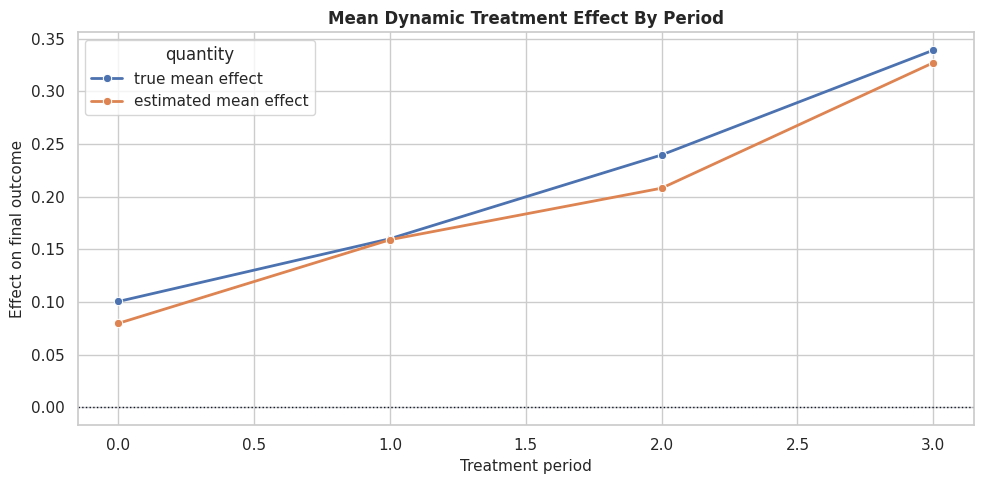

In [16]:
period_mean_plot = period_recovery.melt(
    id_vars="period",
    value_vars=["true_mean_effect", "estimated_mean_effect"],
    var_name="quantity",
    value_name="effect",
)
period_mean_plot["quantity"] = period_mean_plot["quantity"].map(
    {"true_mean_effect": "true mean effect", "estimated_mean_effect": "estimated mean effect"}
)
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=period_mean_plot, x="period", y="effect", hue="quantity", marker="o", linewidth=2, ax=ax)
ax.axhline(0, color="#111827", linestyle=":", linewidth=1)
ax.set_title("Mean Dynamic Treatment Effect By Period")
ax.set_xlabel("Treatment period")
ax.set_ylabel("Effect on final outcome")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "12_dynamic_period_mean_effects.png", dpi=160, bbox_inches="tight")
plt.show()


The plot is the simplest dynamic story: treatment timing matters. Later treatment periods have larger effects in this teaching setup.

This reproducibility check keeps the run auditable before causal interpretation begins. It makes the run consistent enough for later graphs, tables, and estimates to be checked against the same environment.
<!-- result-implication-expanded -->




#### Period-Specific CATE Recovery Plot

Mean effects can look good even when individual heterogeneity is poorly recovered. This plot shows true versus estimated CATE for each treatment period.


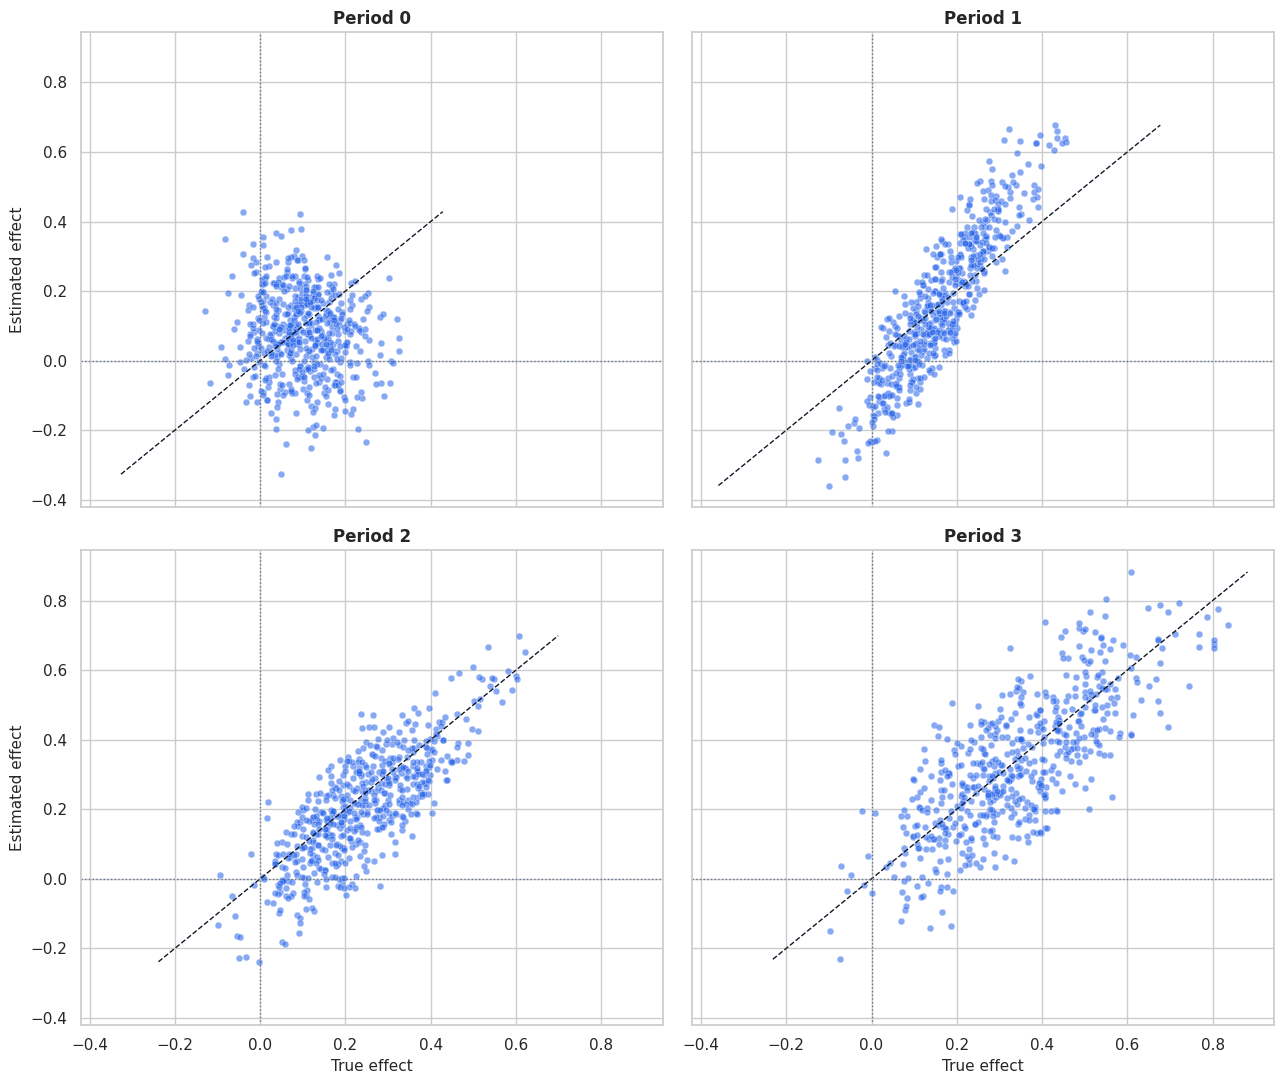

In [17]:
# Build and label the diagnostic visualization for the Period-Specific CATE Recovery Plot section.
period_recovery_plot = pd.concat(
    [
        pd.DataFrame(
            {
                "period": period,
                "true_effect": true_period_effect_matrix[:, period],
                "estimated_effect": dynamic_period_effects[:, period],
            }
        )
        for period in range(n_periods)
    ],
    ignore_index=True,
)
fig, axes = plt.subplots(2, 2, figsize=(13, 11), sharex=True, sharey=True)
for ax, period in zip(axes.ravel(), range(n_periods)):
    subset = period_recovery_plot[period_recovery_plot["period"] == period]
    sns.scatterplot(data=subset, x="true_effect", y="estimated_effect", alpha=0.55, s=24, color="#2563eb", ax=ax)
    lims = [min(subset["true_effect"].min(), subset["estimated_effect"].min()), max(subset["true_effect"].max(), subset["estimated_effect"].max())]
    ax.plot(lims, lims, color="#111827", linestyle="--", linewidth=1)
    ax.axhline(0, color="#64748b", linestyle=":", linewidth=1)
    ax.axvline(0, color="#64748b", linestyle=":", linewidth=1)
    ax.set_title(f"Period {period}")
    ax.set_xlabel("True effect")
    ax.set_ylabel("Estimated effect")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "12_dynamic_period_cate_recovery.png", dpi=160, bbox_inches="tight")
plt.show()


The panels show where heterogeneity is easier or harder to recover. Dynamic CATE estimation is more demanding than a single-period model because it estimates a separate profile for each treatment time.




#### Cumulative Treatment-History Effect

A useful summary is the effect of increasing treatment intensity by one unit in every period. For a linear treatment-history model, that cumulative effect is the sum of the period effects.


In [18]:
zeros = np.zeros((len(X_test_first), n_periods))
ones = np.ones((len(X_test_first), n_periods))
estimated_cumulative_effect_from_effect_call = np.ravel(dynamic_dml.effect(X_test_first, T0=zeros, T1=ones))
cumulative_summary = pd.DataFrame(
    {
        "metric": [
            "true_mean_cumulative_effect",
            "estimated_mean_cumulative_effect_sum",
            "estimated_mean_cumulative_effect_effect_call",
            "rmse",
            "correlation",
            "max_difference_between_sum_and_effect_call",
        ],
        "value": [
            true_cumulative_effect.mean(),
            estimated_cumulative_effect.mean(),
            estimated_cumulative_effect_from_effect_call.mean(),
            np.sqrt(mean_squared_error(true_cumulative_effect, estimated_cumulative_effect)),
            np.corrcoef(true_cumulative_effect, estimated_cumulative_effect)[0, 1],
            np.max(np.abs(estimated_cumulative_effect - estimated_cumulative_effect_from_effect_call)),
        ],
    }
)
cumulative_summary.to_csv(TABLE_DIR / "12_dynamic_cumulative_effect_summary.csv", index=False)
display(cumulative_summary)


,metric,value
0,true_mean_cumulative_effect,8.393493e-01
1,estimated_mean_cumulative_effect_sum,7.742015e-01
2,estimated_mean_cumulative_effect_effect_call,7.742015e-01
3,rmse,1.707591e-01
4,correlation,9.429777e-01
5,max_difference_between_sum_and_effect_call,2.220446e-16


The cumulative effect provides a unit-level summary of the full treatment history. The direct `effect` call and the sum of period effects agree, which is a useful shape sanity check.


#### Cumulative Effect Plot

This plot compares true and estimated cumulative effects for held-out units.


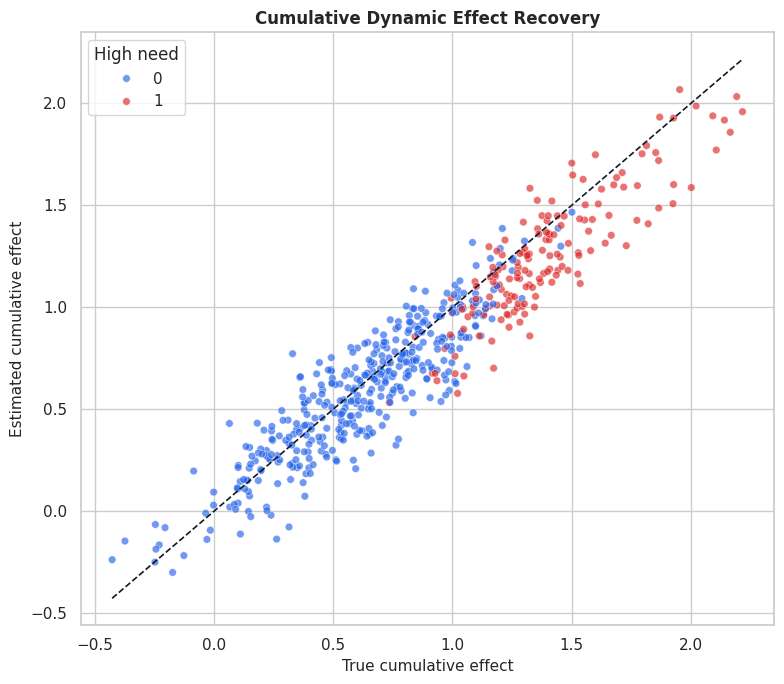

In [19]:
# Build and label the diagnostic visualization for the Cumulative Effect Plot section.
cumulative_plot = pd.DataFrame(
    {
        "true_cumulative_effect": true_cumulative_effect,
        "estimated_cumulative_effect": estimated_cumulative_effect,
        "high_need_segment": first_period_test["high_need_segment"].to_numpy(),
    }
)
fig, ax = plt.subplots(figsize=(8, 7))
sns.scatterplot(
    data=cumulative_plot,
    x="true_cumulative_effect",
    y="estimated_cumulative_effect",
    hue="high_need_segment",
    palette={0: "#2563eb", 1: "#dc2626"},
    alpha=0.65,
    s=30,
    ax=ax,
)
lims = [
    min(cumulative_plot["true_cumulative_effect"].min(), cumulative_plot["estimated_cumulative_effect"].min()),
    max(cumulative_plot["true_cumulative_effect"].max(), cumulative_plot["estimated_cumulative_effect"].max()),
]
ax.plot(lims, lims, color="#111827", linestyle="--", linewidth=1.2)
ax.set_title("Cumulative Dynamic Effect Recovery")
ax.set_xlabel("True cumulative effect")
ax.set_ylabel("Estimated cumulative effect")
ax.legend(title="High need")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "12_dynamic_cumulative_effect_recovery.png", dpi=160, bbox_inches="tight")
plt.show()


The cumulative plot turns four period effects into one unit-level summary. It is useful for ranking units by total treatment-history responsiveness.

That makes the comparison interpretable because differences across methods can be tied to estimator behavior while preprocessing and evaluation stay fixed.
<!-- result-implication-expanded -->


#### Period Treatment Contrast Checks

`DynamicDML.effect` can evaluate custom treatment-history contrasts. The code below verifies that a one-unit increase in a single period matches the corresponding period-specific marginal effect.


In [20]:
contrast_rows = []
for period in range(n_periods):
    t0 = np.zeros((len(X_test_first), n_periods))
    t1 = np.zeros((len(X_test_first), n_periods))
    t1[:, period] = 1
    contrast_effect = np.ravel(dynamic_dml.effect(X_test_first, T0=t0, T1=t1))
    contrast_rows.append(
        {
            "period": period,
            "mean_effect_from_const_marginal_effect": dynamic_period_effects[:, period].mean(),
            "mean_effect_from_custom_contrast": contrast_effect.mean(),
            "max_absolute_row_difference": np.max(np.abs(dynamic_period_effects[:, period] - contrast_effect)),
        }
    )
period_contrast_checks = pd.DataFrame(contrast_rows)
period_contrast_checks.to_csv(TABLE_DIR / "12_dynamic_period_contrast_checks.csv", index=False)
display(period_contrast_checks)


,period,mean_effect_from_const_marginal_effect,mean_effect_from_custom_contrast,max_absolute_row_difference
0,0,0.079794,0.079794,0.0
1,1,0.159156,0.159156,0.0
2,2,0.208101,0.208101,0.0
3,3,0.327150,0.327150,0.0


The custom contrasts match the period-specific marginal effects. This helps students see how to ask counterfactual treatment-history questions with the fitted model.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


#### Coefficient Table

`DynamicDML` uses a linear final CATE model. The coefficient table shows how baseline features modify each period's treatment effect.


In [21]:
coef_array = np.asarray(dynamic_dml.coef_)
intercept_array = np.asarray(dynamic_dml.intercept_)
coef_rows = []
for period in range(n_periods):
    coef_rows.append({"period": period, "feature": "intercept", "coefficient": intercept_array[period]})
    for feature, coefficient in zip(x_cols, coef_array[period]):
        coef_rows.append({"period": period, "feature": feature, "coefficient": coefficient})
dynamic_coefficient_table = pd.DataFrame(coef_rows)
dynamic_coefficient_table.to_csv(TABLE_DIR / "12_dynamic_dml_coefficient_table.csv", index=False)
display(dynamic_coefficient_table.head(20))


,period,feature,coefficient
0,0,intercept,0.224416
1,0,baseline_need,-0.097366
2,0,user_quality,0.036944
3,0,friction_score,0.028478
4,0,price_sensitivity,-0.313846
5,0,region_risk,-0.130273
6,0,high_need_segment,0.060689
7,1,intercept,-0.009794
8,1,baseline_need,0.145013
9,1,user_quality,0.077362


The coefficients are a compact way to see effect modification. Positive baseline-need coefficients in later periods mean higher-need units have larger estimated treatment effects later in the history.


#### Coefficient Heatmap

The heatmap makes period-by-feature coefficient patterns easier to scan than a long table.


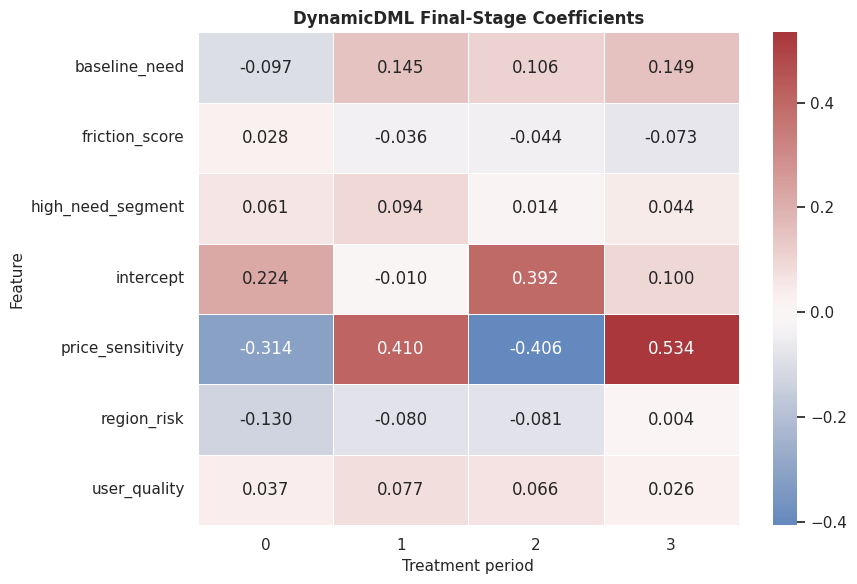

In [22]:
coef_heatmap = dynamic_coefficient_table.pivot(index="feature", columns="period", values="coefficient")
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(coef_heatmap, annot=True, fmt=".3f", cmap="vlag", center=0, linewidths=0.5, ax=ax)
ax.set_title("DynamicDML Final-Stage Coefficients")
ax.set_xlabel("Treatment period")
ax.set_ylabel("Feature")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "12_dynamic_dml_coefficient_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()


The heatmap is a model-explanation output. It shows which baseline features are associated with stronger or weaker treatment-history effects.

For the broader lesson, the estimate should be interpreted together with the identifying assumptions and diagnostics that make it credible.
<!-- result-implication-expanded -->


#### Segment-Level Dynamic Effects

Segment summaries are often easier to explain than row-level effect matrices. The code below compares true and estimated period effects by need segment.


In [23]:
segment_effect_rows = []
for period in range(n_periods):
    period_frame = first_period_test[["unit_id", "high_need_segment", "region_risk"]].copy()
    period_frame["period"] = period
    period_frame["true_effect"] = true_period_effect_matrix[:, period]
    period_frame["estimated_effect"] = dynamic_period_effects[:, period]
    segment_effect_rows.append(period_frame)
segment_effect_long = pd.concat(segment_effect_rows, ignore_index=True)
segment_effect_long["need_segment"] = np.where(segment_effect_long["high_need_segment"] == 1, "high need", "regular need")
segment_effect_summary = (
    segment_effect_long.groupby(["need_segment", "period"], observed=True)
    .agg(
        units=("unit_id", "nunique"),
        true_effect_mean=("true_effect", "mean"),
        estimated_effect_mean=("estimated_effect", "mean"),
        rmse=("estimated_effect", lambda s: np.sqrt(mean_squared_error(segment_effect_long.loc[s.index, "true_effect"], s))),
    )
    .reset_index()
)
segment_effect_summary.to_csv(TABLE_DIR / "12_dynamic_segment_effect_summary.csv", index=False)
display(segment_effect_summary)


,need_segment,period,units,true_effect_mean,estimated_effect_mean,rmse
0,high need,0,159,0.183074,0.006225,0.205566
1,high need,1,159,0.277665,0.385618,0.140863
2,high need,2,159,0.392255,0.332111,0.100621
3,high need,3,159,0.538376,0.525593,0.129148
4,regular need,0,401,0.067808,0.108965,0.127442
5,regular need,1,401,0.113477,0.069362,0.106438
6,regular need,2,401,0.179146,0.158930,0.099399
7,regular need,3,401,0.260037,0.248466,0.126084


The segment table shows how treatment timing and baseline need interact. High-need units generally have stronger effects, especially in later periods.

This matters because the software can only estimate the intended causal quantity when the variables have been assigned to the right design roles.
<!-- result-implication-expanded -->


#### Segment Effect Plot

This plot compares true and estimated effects by period and need segment.


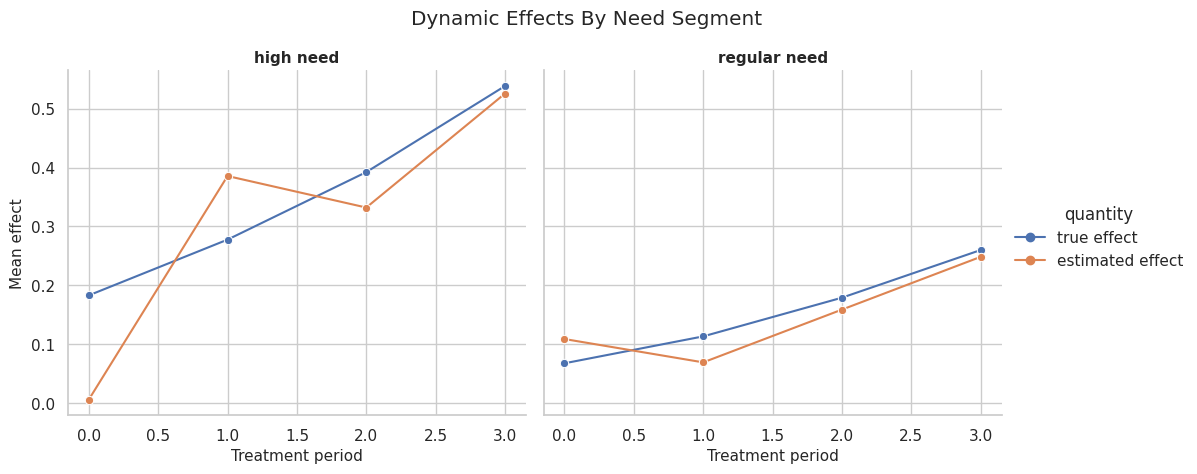

In [24]:
# Build and label the diagnostic visualization for the Segment Effect Plot section.
segment_plot_long = segment_effect_summary.melt(
    id_vars=["need_segment", "period"],
    value_vars=["true_effect_mean", "estimated_effect_mean"],
    var_name="quantity",
    value_name="effect",
)
segment_plot_long["quantity"] = segment_plot_long["quantity"].map(
    {"true_effect_mean": "true effect", "estimated_effect_mean": "estimated effect"}
)
g = sns.relplot(
    data=segment_plot_long,
    x="period",
    y="effect",
    hue="quantity",
    col="need_segment",
    kind="line",
    marker="o",
    height=4.5,
    aspect=1.15,
)
g.set_axis_labels("Treatment period", "Mean effect")
g.set_titles("{col_name}")
g.fig.suptitle("Dynamic Effects By Need Segment", y=1.05)
g.fig.savefig(FIGURE_DIR / "12_dynamic_segment_effects.png", dpi=160, bbox_inches="tight")
plt.show()


The segment plot gives a clean story. Timing matters, and the time pattern differs by baseline need. This kind of chart often belongs in a written conclusion.


#### Policy-Style Treatment-History Ranking

A dynamic effect model can rank units by the estimated value of increasing treatment across the whole history. Here we compare top-20-percent targeting by cumulative dynamic effect against the synthetic truth.


In [25]:
top_share = 0.20
n_top = int(np.floor(top_share * len(X_test_first)))
policy_frame = first_period_test[["unit_id", "high_need_segment", "region_risk", "baseline_need"]].copy()
policy_frame["estimated_cumulative_effect"] = estimated_cumulative_effect
policy_frame["true_cumulative_effect"] = true_cumulative_effect
policy_frame["selected_by_dynamic_rank"] = 0
policy_frame.loc[policy_frame["estimated_cumulative_effect"].nlargest(n_top).index, "selected_by_dynamic_rank"] = 1
policy_frame["oracle_top_cumulative"] = 0
policy_frame.loc[policy_frame["true_cumulative_effect"].nlargest(n_top).index, "oracle_top_cumulative"] = 1
policy_summary = pd.DataFrame(
    [
        {
            "rule": "top 20% by DynamicDML cumulative effect",
            "selected_units": int(policy_frame["selected_by_dynamic_rank"].sum()),
            "selected_share": policy_frame["selected_by_dynamic_rank"].mean(),
            "mean_true_cumulative_effect_selected": policy_frame.loc[policy_frame["selected_by_dynamic_rank"] == 1, "true_cumulative_effect"].mean(),
            "share_high_need_selected": policy_frame.loc[policy_frame["selected_by_dynamic_rank"] == 1, "high_need_segment"].mean(),
        },
        {
            "rule": "oracle top 20% by true cumulative effect",
            "selected_units": int(policy_frame["oracle_top_cumulative"].sum()),
            "selected_share": policy_frame["oracle_top_cumulative"].mean(),
            "mean_true_cumulative_effect_selected": policy_frame.loc[policy_frame["oracle_top_cumulative"] == 1, "true_cumulative_effect"].mean(),
            "share_high_need_selected": policy_frame.loc[policy_frame["oracle_top_cumulative"] == 1, "high_need_segment"].mean(),
        },
        {
            "rule": "all held-out units",
            "selected_units": len(policy_frame),
            "selected_share": 1.0,
            "mean_true_cumulative_effect_selected": policy_frame["true_cumulative_effect"].mean(),
            "share_high_need_selected": policy_frame["high_need_segment"].mean(),
        },
    ]
)
policy_summary.to_csv(TABLE_DIR / "12_dynamic_policy_ranking_summary.csv", index=False)
display(policy_summary)


,rule,selected_units,selected_share,mean_true_cumulative_effect_selected,share_high_need_selected
0,top 20% by DynamicDML cumulative effect,112,0.2,1.498081,0.875000
1,oracle top 20% by true cumulative effect,112,0.2,1.522382,0.946429
2,all held-out units,560,1.0,0.839349,0.283929


The dynamic ranking selects units with higher true cumulative effects than the overall held-out population. The oracle row gives the synthetic upper benchmark.

That makes the comparison interpretable because differences across methods can be tied to estimator behavior while preprocessing and evaluation stay fixed.
<!-- result-implication-expanded -->


#### Policy Ranking Plot

The final policy plot compares true cumulative effects among selected units.


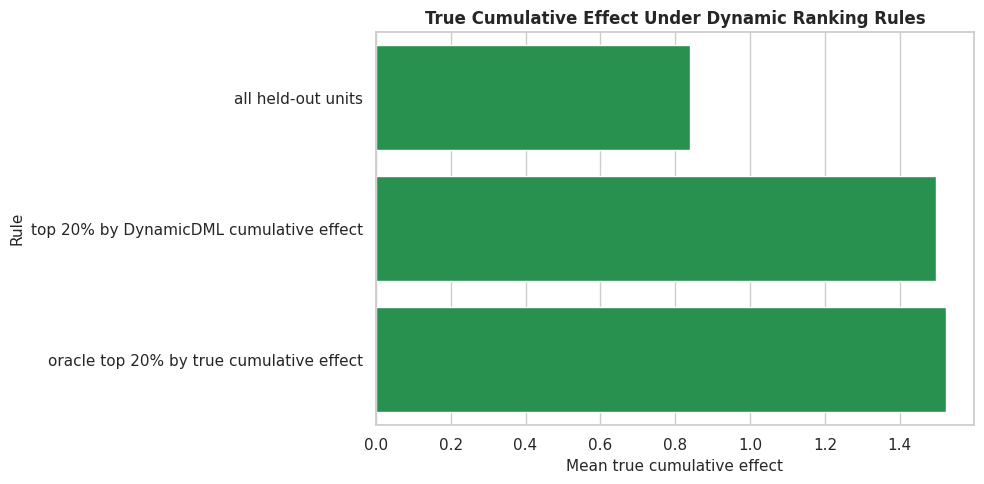

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=policy_summary.sort_values("mean_true_cumulative_effect_selected"),
    x="mean_true_cumulative_effect_selected",
    y="rule",
    color="#16a34a",
    ax=ax,
)
ax.set_title("True Cumulative Effect Under Dynamic Ranking Rules")
ax.set_xlabel("Mean true cumulative effect")
ax.set_ylabel("Rule")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "12_dynamic_policy_ranking_summary.png", dpi=160, bbox_inches="tight")
plt.show()


The plot translates the dynamic CATE matrix into a prioritization decision. It also keeps the comparison honest by showing the all-unit baseline and oracle benchmark.


#### What the Shortcuts Miss

This table summarizes the difference between the pooled shortcut, the last-period snapshot model, and the dynamic panel model.


| workflow | question_answered | main_problem | when_it_can_be_useful |
| --- | --- | --- | --- |
| pooled row-level DML | What is one generic treatment effect if every unit-period row is treated as independent? | Mixes treatment periods and repeats the same final outcome across rows. | Quick exploratory baseline, not a final panel causal design. |
| last-period snapshot DML | What is the effect of final-period treatment on the final outcome? | Ignores earlier treatment effects and treatment-history questions. | When the causal question is explicitly about one period only. |
| DynamicDML | What is the effect of treatment in each period on the final outcome? | Requires balanced histories and credible observed treatment history controls. | When treatment timing and treatment history are central to the decision. |


The dynamic model is most useful when the question depends on treatment timing and past outcomes. It is better matched to treatment-history questions, while a snapshot model is appropriate only for a snapshot estimand.




#### Reporting Checklist

The final checklist turns the lesson into a reusable panel-analysis guide.


| topic | what_to_report | why_it_matters |
| --- | --- | --- |
| Unit and period definition | Define the repeated unit and the treatment periods. | Panel causal questions are built around histories, not isolated rows. |
| Outcome timing | State when the final outcome is measured relative to treatment periods. | Features and treatments must precede the outcome window. |
| Balance and ordering | Check periods per unit, duplicate unit-period rows, and sorting. | DynamicDML expects balanced histories in this implementation. |
| Group splitting | Keep all periods from a unit together in train/test and cross-fitting splits. | Row-level splitting leaks information across time for the same unit. |
| History controls | List the time-varying controls included in W and verify they are pre-treatment. | Sequential ignorability depends on observed treatment history and state. |
| Period effects | Report effects separately by treatment period before collapsing to a cumulative effect. | A single average effect can hide important timing differences. |
| Shortcut caveats | Explain what pooled or snapshot analyses do and do not answer. | Shortcut models often answer narrower or muddier questions than intended. |


The checklist emphasizes timing, grouping, and estimand clarity. Those are the places where longitudinal analyses most often go wrong.

This matters because the software can only estimate the intended causal quantity when the variables have been assigned to the right design roles.
<!-- result-implication-expanded -->


## Summary

We have moved through how to move from cross-sectional treatment effects to dynamic treatment-history effects.

The main lessons are:

- Repeated unit-period rows are not independent cross-sectional observations.
- Panel train-test splits should be done by unit, not by row.
- Time-varying controls must be measured before each period's treatment.
- A pooled row-level model mixes period effects and repeats final outcomes.
- A last-period snapshot model can be coherent but answers only a final-period question.
- `DynamicDML` estimates one final-outcome effect for each treatment period.
- Cumulative treatment-history effects can be formed by summing period effects or by using custom treatment-history contrasts.
- Panel reporting should always state the unit, periods, outcome timing, history controls, and shortcut limitations.

The sequence next compares estimator families on the same simulated ground truth.
